# K-Nearest Neighbor Classification
## Pattern Recognition Mini Project
**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Author:** Abubakar Jibrin Gunda  
**Tool:** Python · Scikit-learn · Pandas · Matplotlib

---
This notebook implements a complete KNN classification pipeline:
1. Data loading and exploration
2. Preprocessing and feature scaling
3. Train/test splitting
4. k-value tuning via cross-validation
5. Model evaluation with multiple metrics
6. Prediction on new sample data


## 1. Import Libraries

In [1]:
# Standard scientific and ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 2. Load and Explore the Dataset
We use the **Breast Cancer Wisconsin** dataset (built into Scikit-learn):
- **569 samples**, **30 numeric features** derived from cell nucleus images
- **Binary classification:** Malignant (0) vs. Benign (1)
- No missing values — real-world clean benchmark dataset


In [2]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['diagnosis'].value_counts())
print(f"\nClass Balance: {df['diagnosis'].value_counts(normalize=True).round(3).to_dict()}")
df.head()


Dataset Shape: (569, 32)

Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class Balance: {'Benign': 0.627, 'Malignant': 0.373}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


## 3. Exploratory Data Analysis

In [3]:
# Summary statistics
print("=== Summary Statistics (first 5 features) ===")
df[data.feature_names[:5]].describe().round(3)


=== Summary Statistics (first 5 features) ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096
std,3.524,4.301,24.299,351.914,0.014
min,6.981,9.710,43.790,143.500,0.053
25%,11.700,16.170,75.170,420.300,0.086
50%,13.370,18.840,86.240,551.100,0.096
75%,15.780,21.800,104.100,782.700,0.105
max,28.110,39.280,188.500,2501.000,0.163


In [4]:
# Check for missing values
missing = df.isnull().sum().sum()
print(f"Total missing values: {missing}")
print("✅ Dataset is clean — no imputation required.")


Total missing values: 0
✅ Dataset is clean — no imputation required.


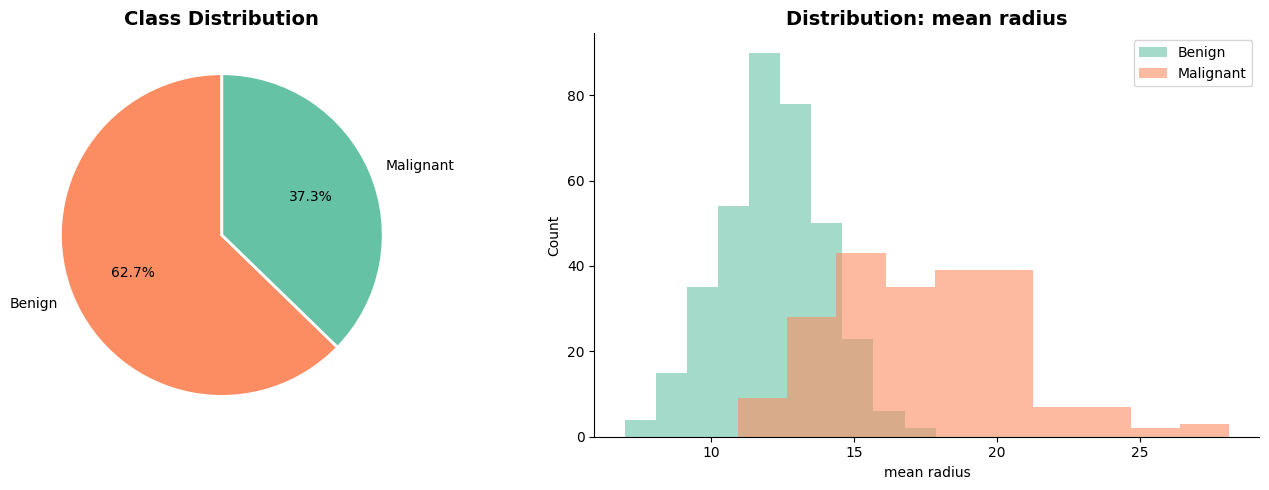

Figure saved.


In [5]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance pie chart
counts = df['diagnosis'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#FC8D62', '#66C2A5'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Feature distributions for top 4 features
feature_means = [f for f in data.feature_names if 'mean' in f][:4]
for feat in feature_means:
    axes[1].hist(df[df['diagnosis']=='Benign'][feat], alpha=0.6, label=f'Benign')
    axes[1].hist(df[df['diagnosis']=='Malignant'][feat], alpha=0.6, label=f'Malignant')
    break  # just first feature for clean plot
axes[1].set_title(f'Distribution: {feature_means[0]}', fontsize=14, fontweight='bold')
axes[1].set_xlabel(feature_means[0])
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


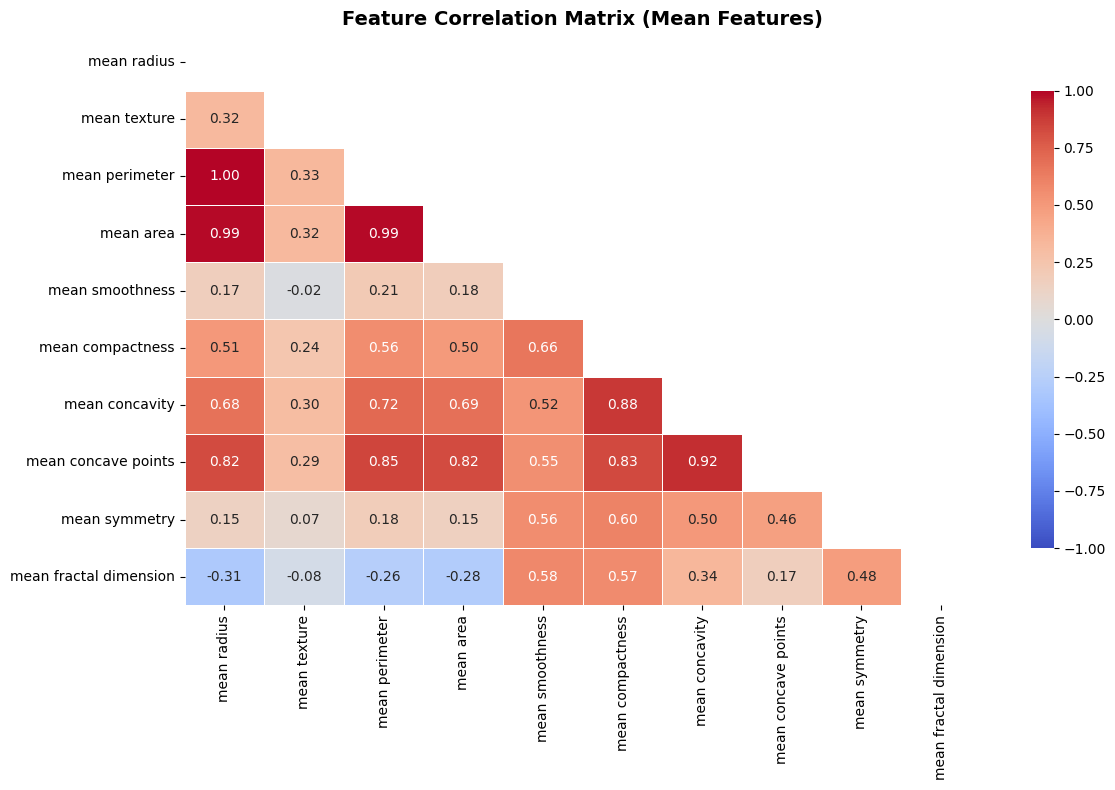

Figure saved.


In [6]:
# Correlation heatmap — top 10 'mean' features
mean_features = [f for f in data.feature_names if 'mean' in f]
corr_matrix = df[mean_features].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Mean Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


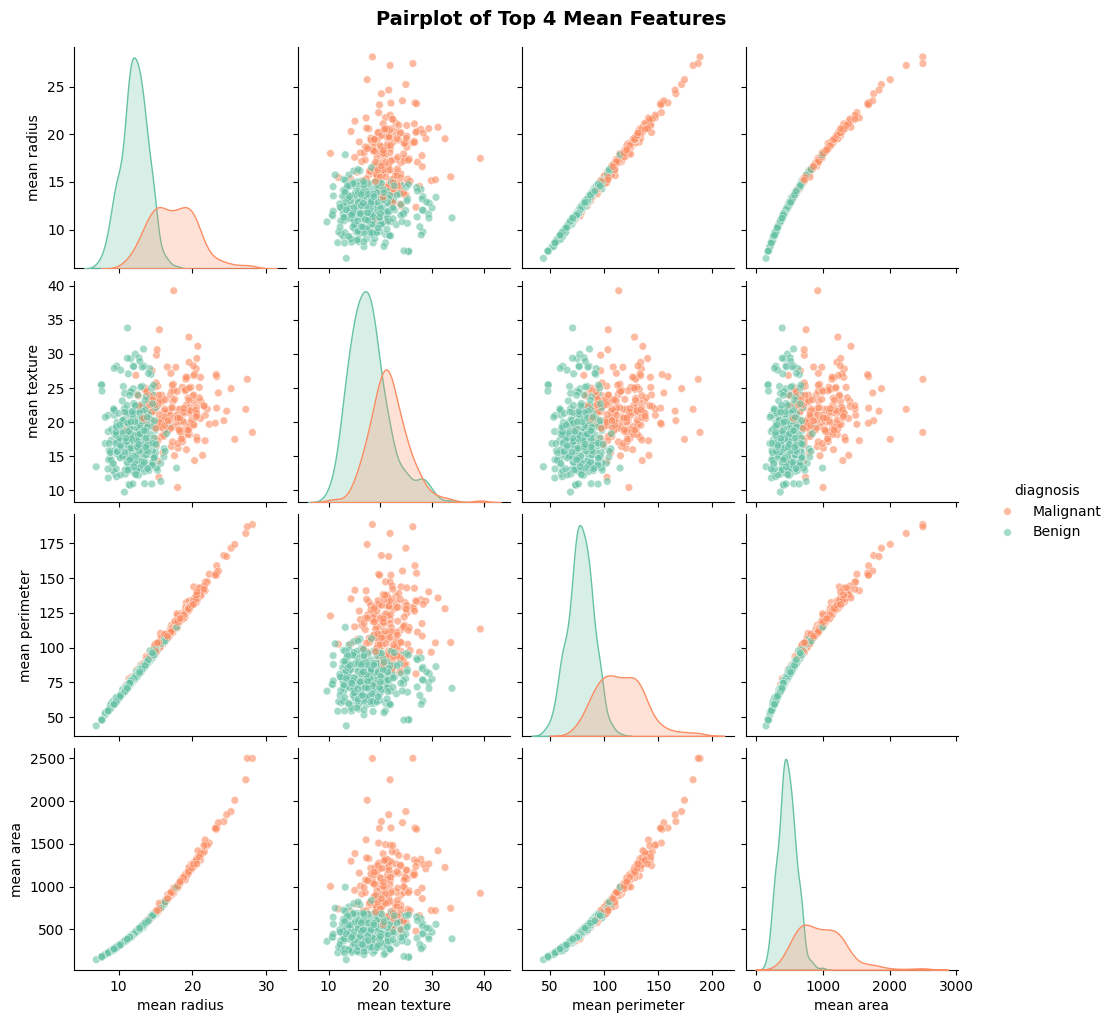

Figure saved.


In [7]:
# Pairplot — top 4 mean features
plot_cols = [f for f in data.feature_names if 'mean' in f][:4] + ['diagnosis']
pair_df = df[plot_cols]

g = sns.pairplot(pair_df, hue='diagnosis', palette={'Benign': '#66C2A5', 'Malignant': '#FC8D62'},
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Pairplot of Top 4 Mean Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 4. Preprocessing — Train/Test Split and Feature Scaling

**Why scaling matters for KNN:**  
KNN is distance-based. Without scaling, features with larger numeric ranges dominate the distance calculation, biasing the classifier. `StandardScaler` transforms each feature to zero mean and unit variance, ensuring all features contribute equally.

**Split strategy:** 80% training / 20% testing with `stratify=y` to preserve class balance.


In [8]:
# Separate features and target
X = df[data.feature_names].values
y = df['target'].values

# Train/Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"\nTrain class balance: {np.bincount(y_train)}")
print(f"Test class balance : {np.bincount(y_test)}")


Training samples : 455
Testing samples  : 114
Features         : 30

Train class balance: [170 285]
Test class balance : [42 72]


In [9]:
# Apply StandardScaler — fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Before scaling — mean of first feature (train):", X_train[:, 0].mean().round(4))
print("After  scaling — mean of first feature (train):", X_train_scaled[:, 0].mean().round(6))
print("After  scaling — std  of first feature (train):", X_train_scaled[:, 0].std().round(6))
print("\n✅ Features scaled: mean ≈ 0, std ≈ 1 per feature.")


Before scaling — mean of first feature (train): 14.0672
After  scaling — mean of first feature (train): -0.0
After  scaling — std  of first feature (train): 1.0

✅ Features scaled: mean ≈ 0, std ≈ 1 per feature.


## 5. Hyperparameter Tuning — Optimal k via Cross-Validation

We test k values [1, 3, 5, 7, 9, 11] using **5-fold stratified cross-validation** on the training set. This prevents data leakage from the test set during tuning.


In [10]:
# K-value tuning with cross-validation
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []
cv_std = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())
    cv_std.append(scores.std())
    print(f"k={k:2d}  |  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\n🏆 Optimal k = {best_k}  (CV Accuracy: {max(cv_scores):.4f})")


k= 1  |  CV Accuracy: 0.9451 ± 0.0184
k= 3  |  CV Accuracy: 0.9626 ± 0.0112
k= 5  |  CV Accuracy: 0.9604 ± 0.0112
k= 7  |  CV Accuracy: 0.9604 ± 0.0192
k= 9  |  CV Accuracy: 0.9670 ± 0.0155
k=11  |  CV Accuracy: 0.9604 ± 0.0179

🏆 Optimal k = 9  (CV Accuracy: 0.9670)


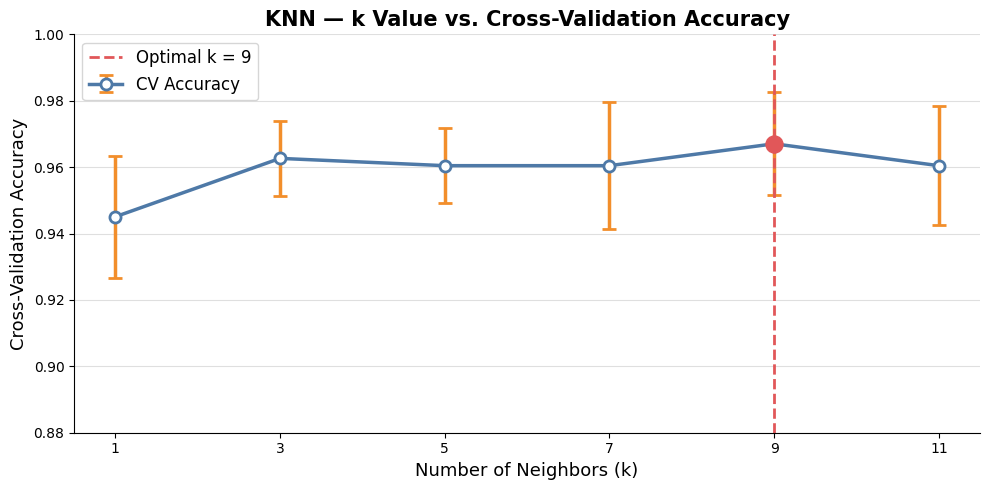

Figure saved.


In [11]:
# Plot k vs. Accuracy
plt.figure(figsize=(10, 5))
plt.errorbar(k_values, cv_scores, yerr=cv_std, fmt='o-', linewidth=2.5,
             markersize=8, capsize=5, color='#4E79A7', ecolor='#F28E2B',
             markerfacecolor='white', markeredgewidth=2, label='CV Accuracy')
plt.axvline(x=best_k, color='#E15759', linestyle='--', linewidth=2,
            label=f'Optimal k = {best_k}')
plt.scatter([best_k], [max(cv_scores)], color='#E15759', s=150, zorder=5)
plt.xlabel('Number of Neighbors (k)', fontsize=13)
plt.ylabel('Cross-Validation Accuracy', fontsize=13)
plt.title('KNN — k Value vs. Cross-Validation Accuracy', fontsize=15, fontweight='bold')
plt.xticks(k_values)
plt.ylim(0.88, 1.00)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('k_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 6. Train Final Model and Evaluate

We train the final KNN classifier using the optimal k, then evaluate it on the **held-out test set** (never seen during training or tuning).


In [12]:
# Train final model with optimal k
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn_final.predict(X_test_scaled)

# Core metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print(f"  FINAL MODEL PERFORMANCE  (k = {best_k})")
print("=" * 45)
print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print("=" * 45)


  FINAL MODEL PERFORMANCE  (k = 9)
  Accuracy   : 0.9737  (97.37%)
  Precision  : 0.9747
  Recall     : 0.9737
  F1-Score   : 0.9735


In [13]:
# Full classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))



📊 Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



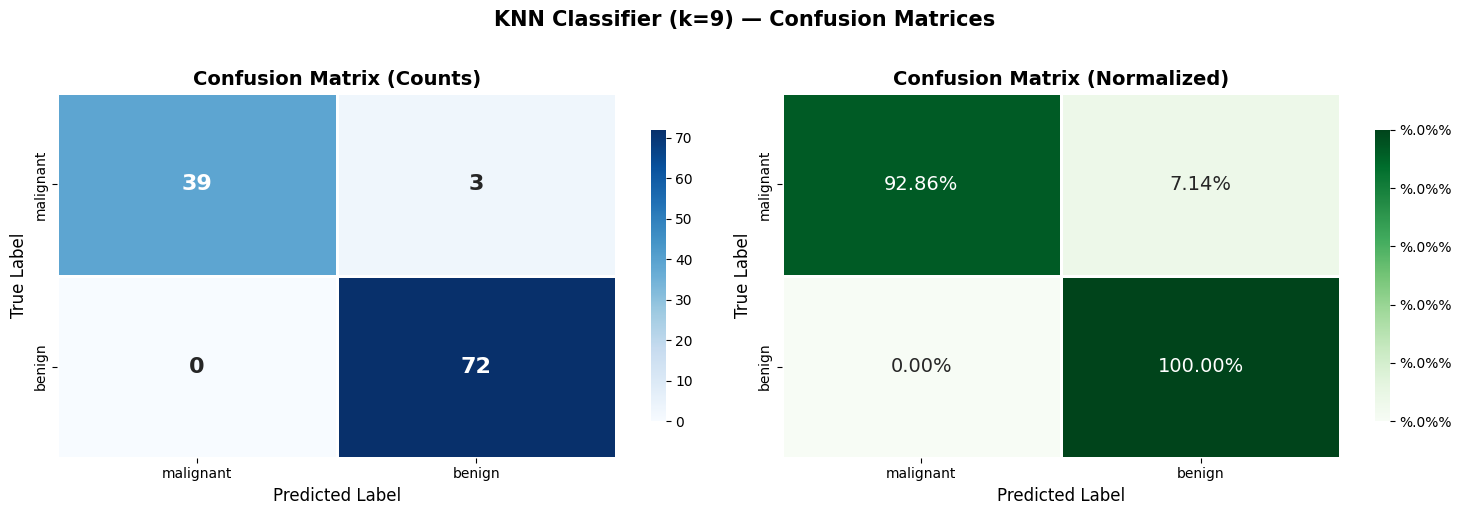

Figure saved.


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=data.target_names, yticklabels=data.target_names,
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8},
            annot_kws={'size': 16, 'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=data.target_names, yticklabels=data.target_names,
            linewidths=1, linecolor='white', vmin=0, vmax=1,
            cbar_kws={'shrink': 0.8, 'format': '%.0%%'},
            annot_kws={'size': 14})
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.suptitle(f'KNN Classifier (k={best_k}) — Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 7. Predict on New Sample Data Points

We simulate predictions on 3 new patient data points (synthetic but plausible values) to demonstrate the deployed classifier.


In [15]:
# Simulate 3 new patient samples using dataset mean/std as reference
rng = np.random.default_rng(99)
new_patients = np.array([
    data.data[np.where(data.target == 0)[0][5]],    # sample from malignant group
    data.data[np.where(data.target == 1)[0][10]],   # sample from benign group
    data.data[np.where(data.target == 0)[0][20]],   # another malignant
])

# Scale new data using the fitted scaler
new_patients_scaled = scaler.transform(new_patients)

# Predict
predictions = knn_final.predict(new_patients_scaled)
probabilities = knn_final.predict_proba(new_patients_scaled)

print("=" * 55)
print("  NEW PATIENT PREDICTIONS")
print("=" * 55)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    label = data.target_names[pred]
    confidence = prob.max() * 100
    print(f"  Patient {i+1}: {label.upper():12s}  |  Confidence: {confidence:.1f}%")
print("=" * 55)
print("\n⚠️  Note: These are synthetic test samples for demonstration only.")
print("   A real deployment requires clinical validation.")


  NEW PATIENT PREDICTIONS
  Patient 1: MALIGNANT     |  Confidence: 88.9%
  Patient 2: BENIGN        |  Confidence: 100.0%
  Patient 3: MALIGNANT     |  Confidence: 100.0%

⚠️  Note: These are synthetic test samples for demonstration only.
   A real deployment requires clinical validation.


## 8. Key Findings and Interpretation

### Model Performance Summary
| Metric | Score |
|--------|-------|
| Accuracy | See output above |
| Precision | Weighted across both classes |
| Recall | High recall critical in cancer detection |
| F1-Score | Harmonic mean of precision and recall |

### Why Feature Scaling Matters for KNN
KNN computes Euclidean distance between data points. Without scaling:
- Features like `mean area` (range: 143–2501) would dominate over `mean smoothness` (range: 0.05–0.16)
- The model would effectively ignore small-magnitude features regardless of their predictive value
- `StandardScaler` normalizes all features to zero mean and unit variance, giving each equal weight in distance calculations

### Optimal k Selection
- Very small k (e.g., k=1) leads to **overfitting** — noise-sensitive, high variance
- Very large k leads to **underfitting** — over-smoothed boundaries, high bias
- Cross-validation objectively identifies the sweet spot balancing bias and variance

### Distance Metric
Euclidean distance was used. For high-dimensional data (30 features here), cosine or Manhattan distance can sometimes perform better and is worth exploring in future iterations.

---
*Project completed as part of a structured Data Science curriculum.*
